# Applying Central Limit Theorem with Simulations

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply Central Limit Theorem with simulations
- Understand how sample means converge to normal distribution
- Visualize CLT with different sample sizes and distributions
- Demonstrate CLT with real examples

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 3, lesson 01 "03. Learning under Uncertainty" — why sampling variation is unavoidable; the CLT says what shape that variation takes.

---

This notebook covers practical activities from **Course 03, Unit 5**:
- Applying Central Limit Theorem with simulations

---

## Introduction

**Central Limit Theorem (CLT)** states that the distribution of sample means approaches a normal distribution as sample size increases, regardless of the original population distribution.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy for the resampling, Matplotlib for the histograms, scipy.stats for the
# reference normal curves, and pandas/sklearn to load the REAL populations we sample from.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import fetch_california_housing

from pathlib import Path


def data_path(filename):
    """Locate a shared raw dataset by walking up from this notebook's folder.

    All courses share one datasets folder, so we search upward for it instead of
    hard-coding a fragile relative path.
    """
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidate = base / "Course 04" / "datasets" / "raw" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"{filename} not found under any Course 04/datasets/raw")


# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nApplying Central Limit Theorem with Simulations")
print("=" * 60)


✅ Libraries imported!

Applying Central Limit Theorem with Simulations


## Part 1: CLT with Uniform Distribution


Part 1: CLT with a Real, Skewed Population

Original population: 891 real Titanic ticket fares (in 1912 pounds)
Population mean: 32.2042
Population std: 49.6655
Population skewness: 4.78  -> strongly right-skewed,
nothing like a bell curve: most passengers paid under 15 pounds, a few paid over 200.

Sample size 2:
  Mean of sample means: 32.3109
  Std of sample means: 36.0232
  Theoretical std (σ/√n): 35.1188
  Skewness of the sample means: 3.511

Sample size 5:
  Mean of sample means: 32.5470
  Std of sample means: 22.5430
  Theoretical std (σ/√n): 22.2111
  Skewness of the sample means: 2.125

Sample size 10:
  Mean of sample means: 32.0190
  Std of sample means: 15.5245
  Theoretical std (σ/√n): 15.7056
  Skewness of the sample means: 1.484

Sample size 30:
  Mean of sample means: 32.2393
  Std of sample means: 9.0730
  Theoretical std (σ/√n): 9.0676
  Skewness of the sample means: 0.860



Sample size 100:
  Mean of sample means: 32.1611
  Std of sample means: 4.9473
  Theoretical std (σ/√n): 4.9666
  Skewness of the sample means: 0.486


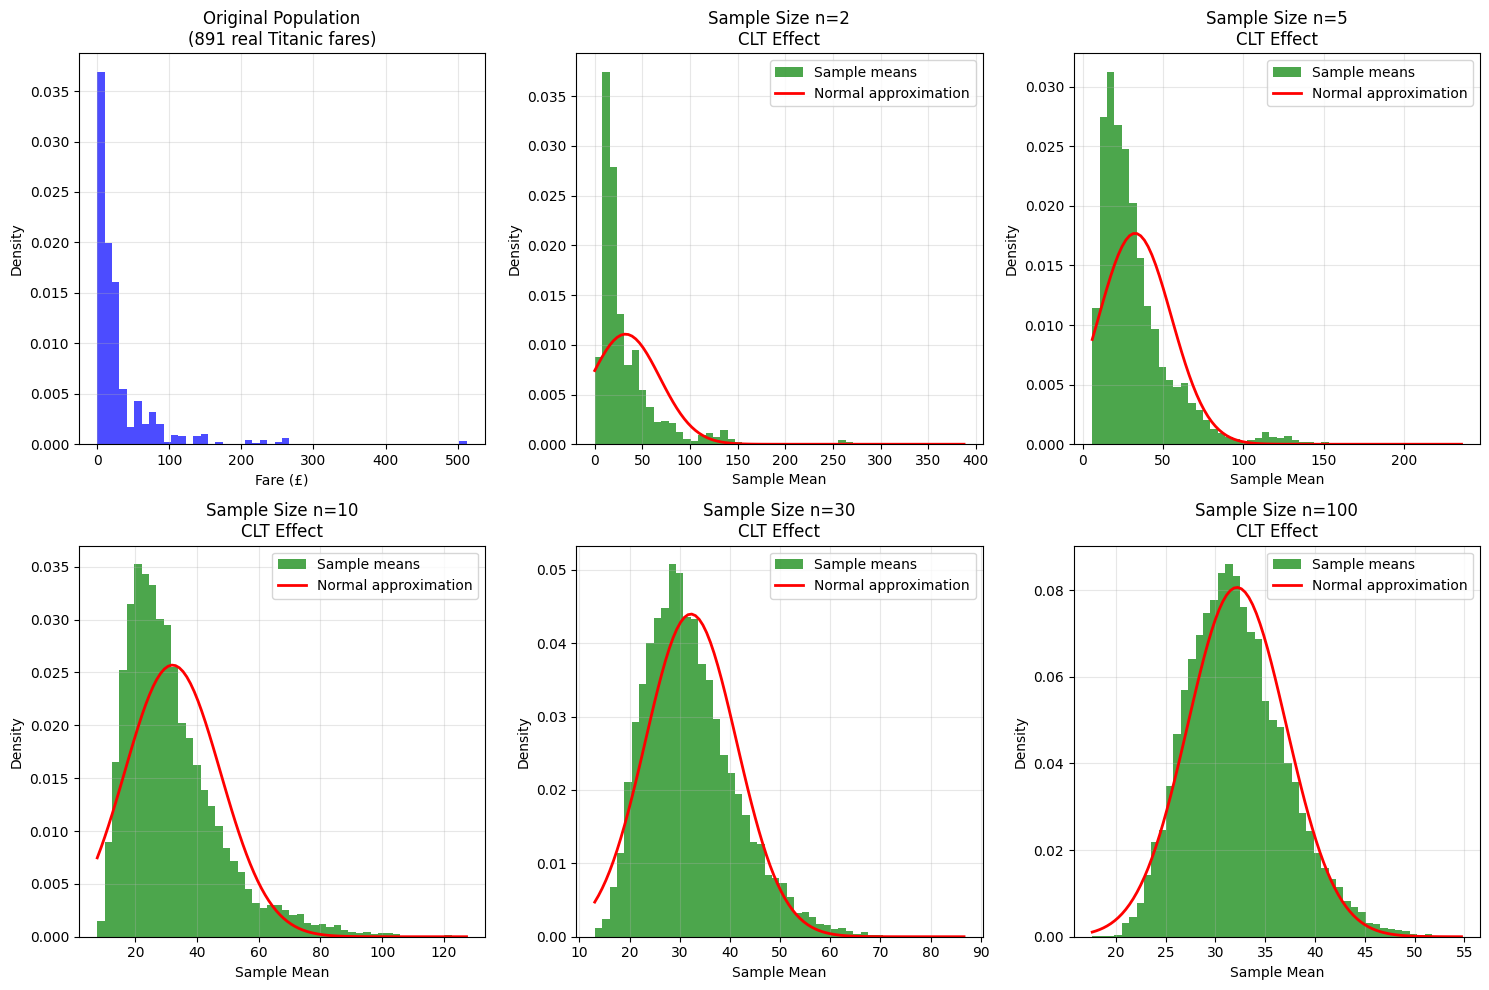


Read the skewness column, not just the pictures. The population's own skew is 4.78;
the sample means fall from 3.51 at n=2 to 0.49 at n=100.
That is the CLT working - and also its honest small print: with a population this
heavy-tailed, even n=100 has not reached a perfectly symmetric bell. The convergence
is real but gradual, which is why the usual 'n >= 30 is enough' rule is a guideline,
not a guarantee.

✅ CLT demonstrated on a real skewed population!


In [2]:
# Simulate the Central Limit Theorem on a REAL, badly-behaved population: the ticket fares
# actually paid by the 891 passengers on the Titanic. Draw many samples and histogram their means.
# As the sample size n grows, the means turn bell-shaped and their spread shrinks like sigma/sqrt(n).
#
# (np.random.choice here IS the lesson: repeated sampling is what the theorem is about.
#  The population itself is real - we did not invent a single fare.)

print("=" * 60)
print("Part 1: CLT with a Real, Skewed Population")
print("=" * 60)

np.random.seed(42)

titanic = pd.read_csv(data_path("titanic.csv"))
population = titanic["Fare"].dropna().to_numpy()

print(f"\nOriginal population: {len(population)} real Titanic ticket fares (in 1912 pounds)")
print(f"Population mean: {population.mean():.4f}")
print(f"Population std: {population.std():.4f}")
print(f"Population skewness: {stats.skew(population):.2f}  -> strongly right-skewed,")
print("nothing like a bell curve: most passengers paid under 15 pounds, a few paid over 200.")

# Simulate CLT with different sample sizes
sample_sizes = [2, 5, 10, 30, 100]
n_simulations = 10000

sample_means = {}
for n in sample_sizes:
    means = []
    for _ in range(n_simulations):
        sample = np.random.choice(population, size=n, replace=True)
        means.append(sample.mean())
    sample_means[n] = np.array(means)
    print(f"\nSample size {n}:")
    print(f"  Mean of sample means: {sample_means[n].mean():.4f}")
    print(f"  Std of sample means: {sample_means[n].std():.4f}")
    print(f"  Theoretical std (σ/√n): {population.std()/np.sqrt(n):.4f}")
    print(f"  Skewness of the sample means: {stats.skew(sample_means[n]):.3f}")

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original population
axes[0, 0].hist(population, bins=50, density=True, alpha=0.7, color='blue')
axes[0, 0].set_title('Original Population\n(891 real Titanic fares)')
axes[0, 0].set_xlabel('Fare (£)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].grid(True, alpha=0.3)

# Sample means for different sample sizes
for idx, n in enumerate(sample_sizes):
    row = (idx + 1) // 3
    col = (idx + 1) % 3
    ax = axes[row, col]

    ax.hist(sample_means[n], bins=50, density=True, alpha=0.7, color='green', label='Sample means')

    # Overlay normal distribution
    mean_means = sample_means[n].mean()
    std_means = sample_means[n].std()
    x = np.linspace(sample_means[n].min(), sample_means[n].max(), 100)
    y = stats.norm.pdf(x, mean_means, std_means)
    ax.plot(x, y, 'r-', linewidth=2, label='Normal approximation')

    ax.set_title(f'Sample Size n={n}\nCLT Effect')
    ax.set_xlabel('Sample Mean')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nRead the skewness column, not just the pictures. The population's own skew is "
      f"{stats.skew(population):.2f};")
print(f"the sample means fall from {stats.skew(sample_means[sample_sizes[0]]):.2f} at n={sample_sizes[0]} "
      f"to {stats.skew(sample_means[sample_sizes[-1]]):.2f} at n={sample_sizes[-1]}.")
print("That is the CLT working - and also its honest small print: with a population this")
print("heavy-tailed, even n=100 has not reached a perfectly symmetric bell. The convergence")
print("is real but gradual, which is why the usual 'n >= 30 is enough' rule is a guideline,")
print("not a guarantee.")
print("\n✅ CLT demonstrated on a real skewed population!")


## Part 2: CLT with Different Distributions



Part 2: CLT with Different Real Populations

Titanic fares (£):
  Population size: 891   skewness: 4.779
  Population mean: 32.2042
  Mean of sample means: 32.1840
  Std of sample means: 9.0675   (theory σ/√n = 9.0676)

Titanic ages (years):
  Population size: 714   skewness: 0.388
  Population mean: 29.6991
  Mean of sample means: 29.6778
  Std of sample means: 2.5952   (theory σ/√n = 2.6503)

California house age (years):
  Population size: 20640   skewness: 0.060
  Population mean: 28.6395
  Mean of sample means: 28.6466
  Std of sample means: 2.3319   (theory σ/√n = 2.2977)


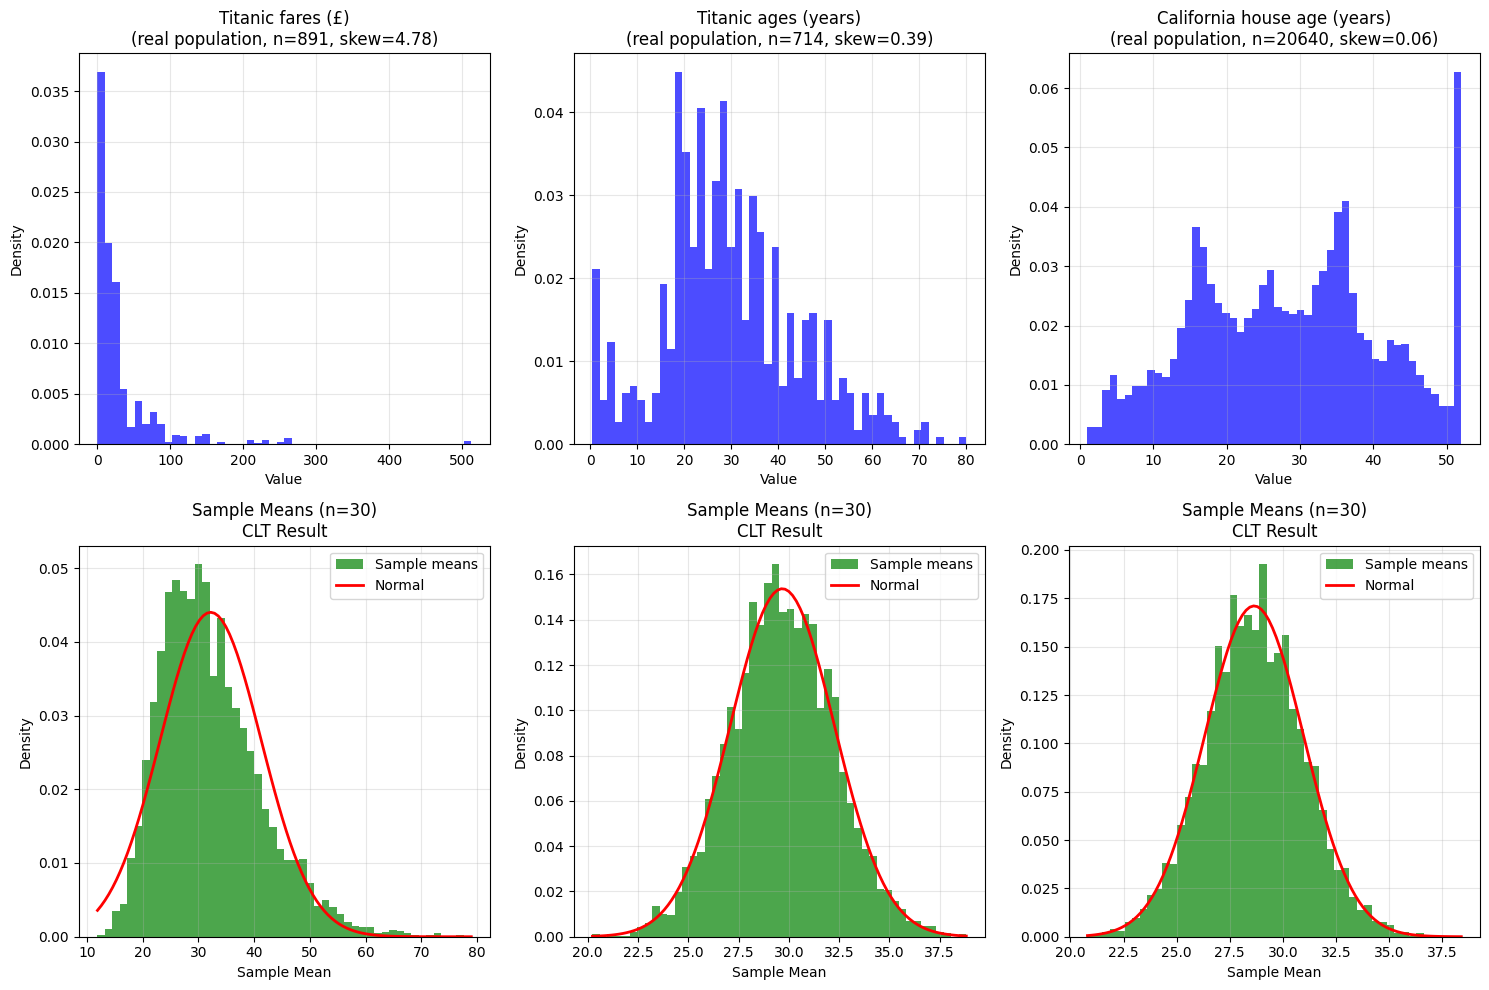


The top row shows three populations that look nothing alike - a long-tailed fare
distribution, a roughly bell-shaped age distribution, and a bounded, almost flat one.
The bottom row shows their sample means, and all three are close to normal.

✅ CLT demonstrated on three real populations!


In [3]:
# Stress-test the CLT on three REAL populations with genuinely different shapes.
# Whatever the starting shape, means of n=30 samples already look normal - that is the theorem's power.
# (Again: the sampling is simulated on purpose; every population below is measured data.)

print("\n" + "=" * 60)
print("Part 2: CLT with Different Real Populations")
print("=" * 60)

housing = fetch_california_housing()
ages = titanic["Age"].dropna().to_numpy()

# Three real populations, three different shapes
distributions = {
    'Titanic fares (£)': population,
    'Titanic ages (years)': ages,
    'California house age (years)': housing.data[:, housing.feature_names.index('HouseAge')],
}

n_samples = 30
n_simulations = 5000

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, (name, pop) in enumerate(distributions.items()):
    # Original distribution
    axes[0, idx].hist(pop, bins=50, density=True, alpha=0.7, color='blue')
    axes[0, idx].set_title(f'{name}\n(real population, n={len(pop)}, skew={stats.skew(pop):.2f})')
    axes[0, idx].set_xlabel('Value')
    axes[0, idx].set_ylabel('Density')
    axes[0, idx].grid(True, alpha=0.3)

    # Sample means
    means = []
    for _ in range(n_simulations):
        sample = np.random.choice(pop, size=n_samples, replace=True)
        means.append(sample.mean())
    means = np.array(means)

    axes[1, idx].hist(means, bins=50, density=True, alpha=0.7, color='green', label='Sample means')

    # Normal approximation
    mean_means = means.mean()
    std_means = means.std()
    x = np.linspace(means.min(), means.max(), 100)
    y = stats.norm.pdf(x, mean_means, std_means)
    axes[1, idx].plot(x, y, 'r-', linewidth=2, label='Normal')

    axes[1, idx].set_title(f'Sample Means (n={n_samples})\nCLT Result')
    axes[1, idx].set_xlabel('Sample Mean')
    axes[1, idx].set_ylabel('Density')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

    print(f"\n{name}:")
    print(f"  Population size: {len(pop)}   skewness: {stats.skew(pop):.3f}")
    print(f"  Population mean: {pop.mean():.4f}")
    print(f"  Mean of sample means: {mean_means:.4f}")
    print(f"  Std of sample means: {std_means:.4f}   (theory σ/√n = {pop.std()/np.sqrt(n_samples):.4f})")

plt.tight_layout()
plt.show()

print("\nThe top row shows three populations that look nothing alike - a long-tailed fare")
print("distribution, a roughly bell-shaped age distribution, and a bounded, almost flat one.")
print("The bottom row shows their sample means, and all three are close to normal.")
print("\n✅ CLT demonstrated on three real populations!")


## Summary

### Key Concepts:
1. **Central Limit Theorem**: Sample means approach normal distribution as n increases
2. **Sample Size**: Larger samples lead to better normal approximation
3. **Distribution Independence**: CLT works regardless of original distribution
4. **Standard Error**: σ/√n decreases as sample size increases
5. **Practical Application**: Enables statistical inference on sample means

### Best Practices:
- Use sample size n ≥ 30 for good CLT approximation
- Verify assumptions before applying CLT
- Understand that CLT applies to means, not individual observations
- Use CLT for confidence intervals and hypothesis testing

### Applications:
- Statistical inference
- Confidence intervals
- Hypothesis testing
- Sampling theory

**Reference:** Course 03, Unit 5: "Probability and Statistical Inference" - Central Limit Theorem practical content

## 📚 References

1. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 3: Probability and Information Theory. MIT Press. <https://www.deeplearningbook.org/>
2. Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*, Ch. 6: Probability and Distributions. Cambridge University Press. <https://mml-book.github.io/>
3. Efron, B. (1979). *Bootstrap Methods: Another Look at the Jackknife*. The Annals of Statistics, 7(1), 1–26.